<a href="https://colab.research.google.com/github/vaishnavipokhriyal083-sudo/Insurance_Data_Project/blob/main/Insurance_Data_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Problem Statement***

The objective of this project is to develop a machine learning model that accurately predicts individual medical insurance charges based on demographic and lifestyle factors such as age, sex, BMI, number of children, smoking status, and region. The project compares the performance of Linear Regression, Decision Tree Regressor, Random Forest Regressor, and XGBoost Regressor using evaluation metrics such as R² Score, MAE, MSE, and RMSE to identify the most accurate model for insurance cost prediction.

In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [156]:
df= pd.read_csv("/content/new_insurance_data (1).csv")

In [157]:
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.210,0.0,no,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.140,0.0,no,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.330,0.0,no,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.660,0.0,no,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.100,0.0,no,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,northwest,55135.40209
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,northeast,58571.07448
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,northwest,60021.39897
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,southeast,62592.87309


In [227]:
df.head()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,1,23.21,0.0,0,29087.54313,17.0,715428.0,4720920.992,0.0,55784970.05,2,1121.8739
1,18.0,1,30.14,0.0,0,39053.67437,7.0,699157.0,4329831.676,0.0,13700885.19,2,1131.5066
2,18.0,1,33.33,0.0,0,39023.62759,19.0,702341.0,6884860.774,0.0,73523107.27,2,1135.9407
3,18.0,1,33.66,0.0,0,28185.39332,11.0,700250.0,4274773.550,0.0,75819679.60,2,1136.3994
4,18.0,1,34.10,0.0,0,14697.85941,16.0,711584.0,3787293.921,0.0,23012320.01,2,1137.0110


In [158]:
# EDA : Exploratory Data analysis

# null values
# Duplicates
# outliers
# label encoding

In [159]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

In [160]:
df.describe()

,age,bmi,children,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,charges
count,1329.000000,1335.000000,1333.000000,1324.000000,1332.000000,1.335000e+03,1.334000e+03,1336.000000,1.332000e+03,1338.000000
mean,39.310008,30.665112,1.090773,33361.327180,15.216216,9.100047e+05,1.584179e+07,1.060629,3.696849e+08,13270.422265
std,14.034818,6.101690,1.201856,15617.288337,7.467723,9.188612e+04,2.669305e+07,0.533583,5.668843e+08,12110.011237
min,18.000000,15.960000,0.000000,1920.136268,1.000000,6.954300e+05,2.945253e+04,0.000000,2.747072e+06,1121.873900
25%,27.000000,26.302500,0.000000,20768.860390,9.000000,8.471995e+05,4.077633e+06,1.000000,7.701932e+07,4740.287150
50%,39.000000,30.400000,1.000000,33700.310675,15.000000,9.143000e+05,7.490337e+06,1.000000,1.419361e+08,9382.033000
75%,51.000000,34.687500,2.000000,45052.331957,20.000000,9.716840e+05,1.084082e+07,1.000000,3.243499e+08,16639.912515
max,64.000000,53.130000,5.000000,77277.988480,40.000000,1.107872e+06,2.616317e+08,3.000000,4.117197e+09,63770.428010


In [161]:
df.isnull()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,False,False,False,False,False,False,False,False,False,False,False,False,False
1334,False,False,False,False,False,False,False,False,False,False,False,False,False
1335,False,False,False,False,False,False,False,False,False,False,False,False,False
1336,False,False,False,False,False,False,False,False,False,False,False,False,False


In [162]:
df.isnull().sum()

,0
age,9
sex,0
bmi,3
children,5
smoker,0
Claim_Amount,14
past_consultations,6
num_of_steps,3
Hospital_expenditure,4
NUmber_of_past_hospitalizations,2


In [163]:
df.isnull().sum().sum()

np.int64(52)

In [164]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='object')

In [165]:
# Duplicates
df.duplicated().sum()

np.int64(0)

In [166]:
# What if we had duplicate values
# df.drop_duplicates(inplace =True)

In [167]:
for col in df.columns:
  if df[col].dtype=="object":
    df[col] = df[col].fillna(df[col].mode([0]))
  else:
    df[col] = df[col].fillna(df[col].mean())

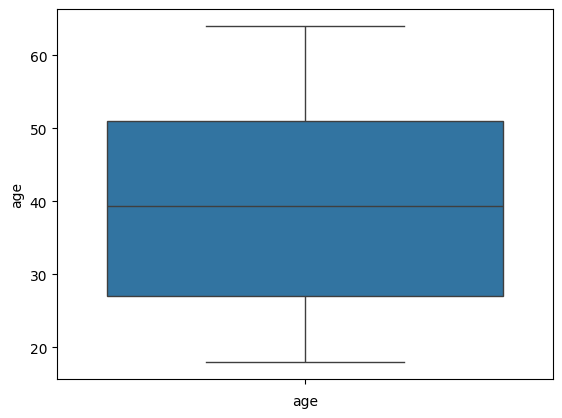

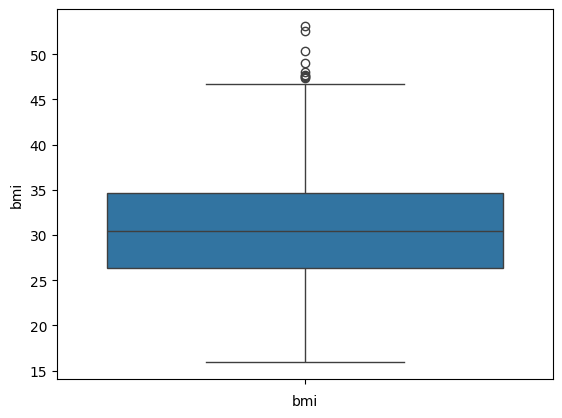

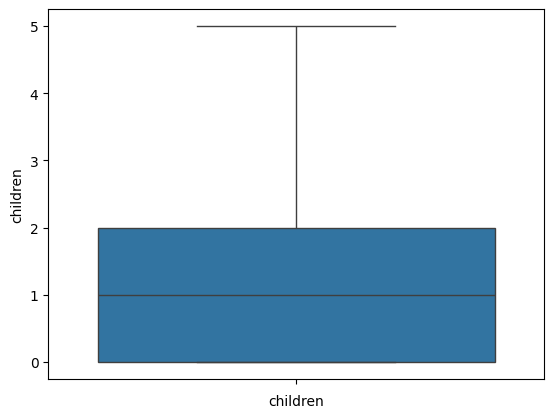

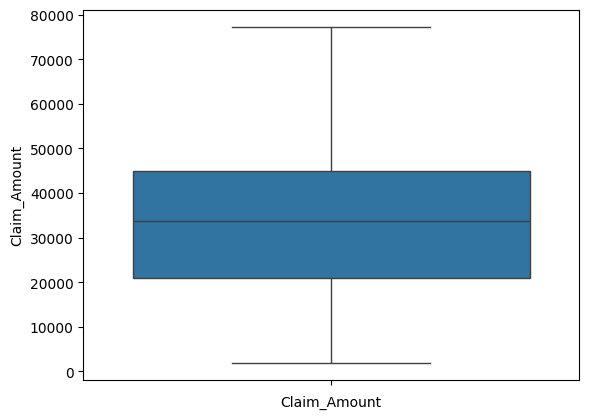

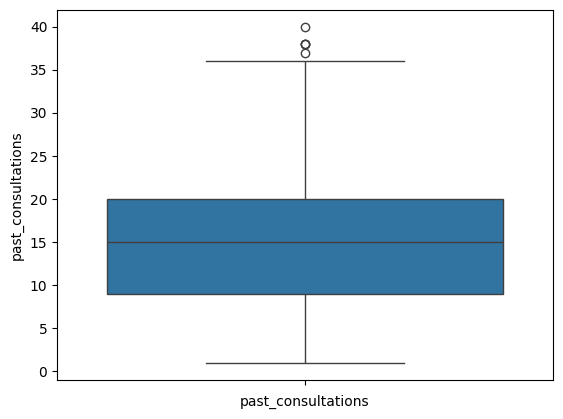

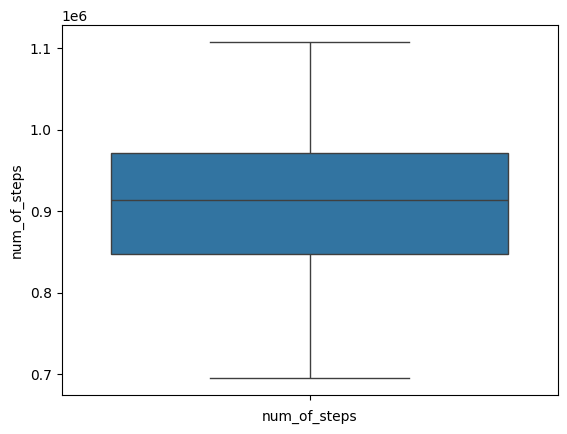

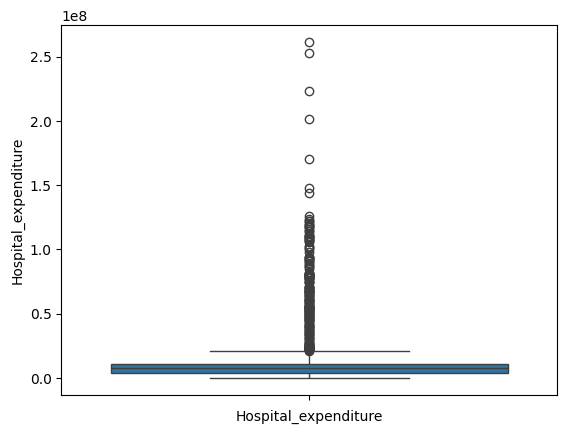

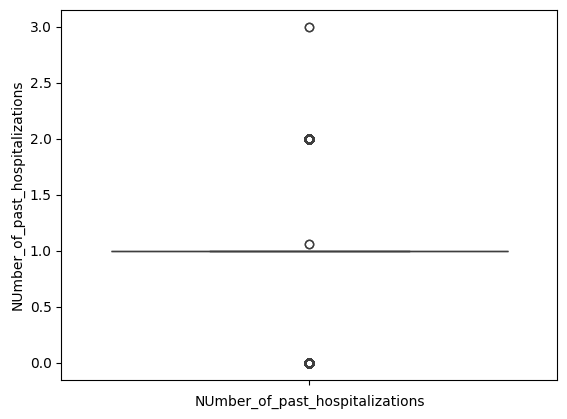

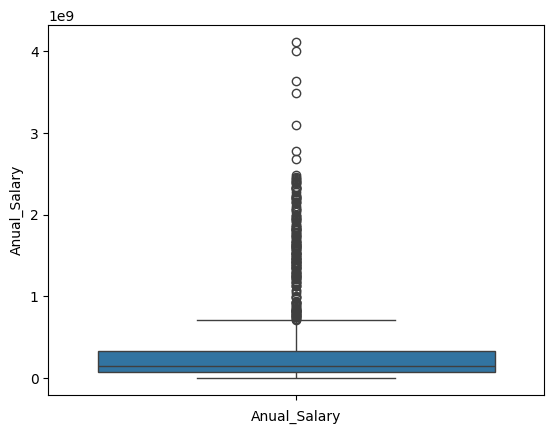

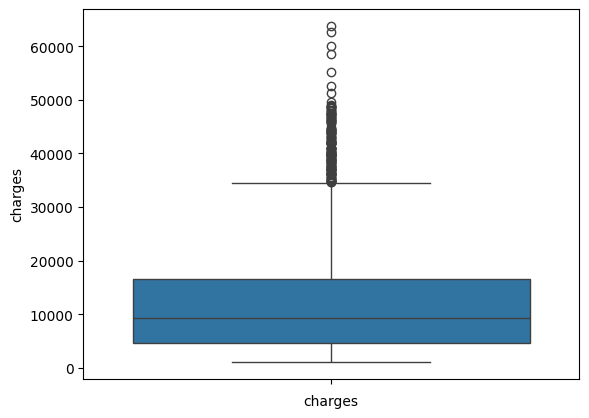

In [168]:
for col in df.columns:
  if (df[col].dtype!= 'object'):
   sns.boxplot(df[col])
   plt.xlabel(col)
   plt.show()

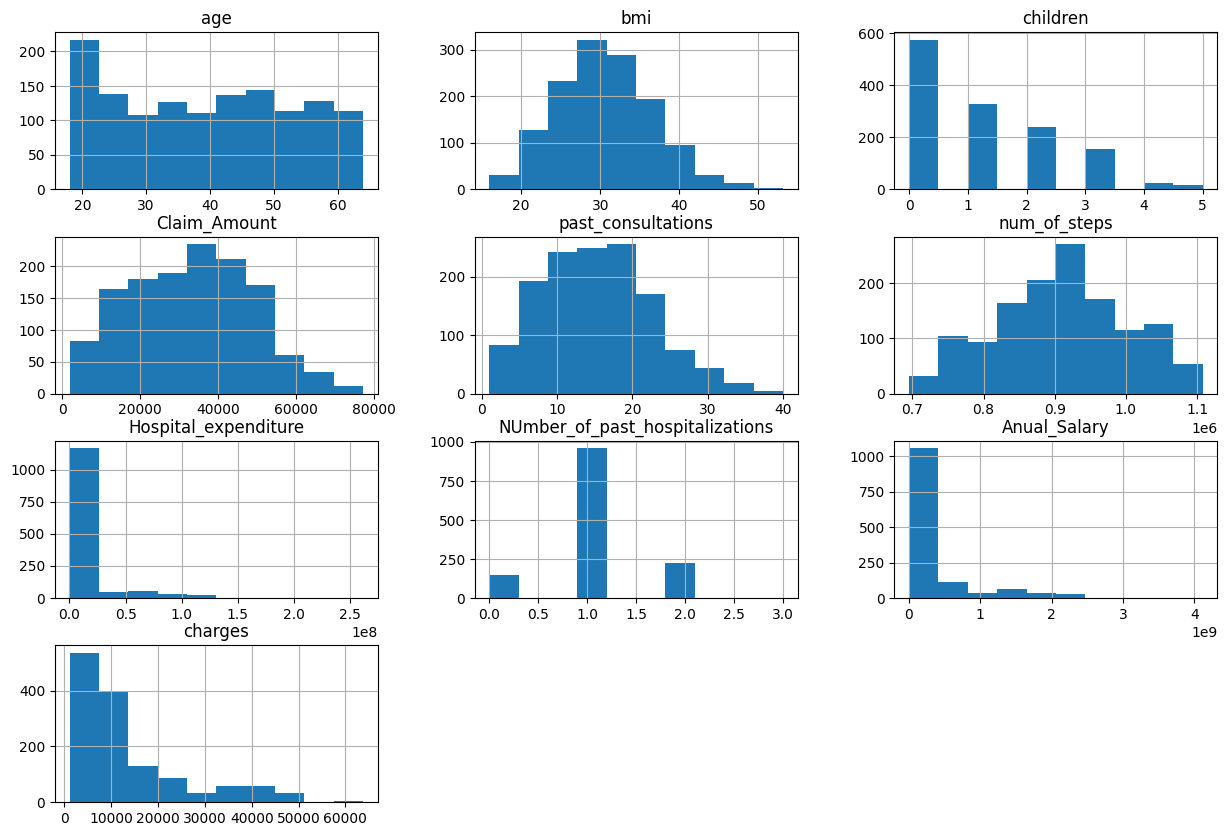

In [169]:
df.hist(figsize=(15,10))
plt.show()

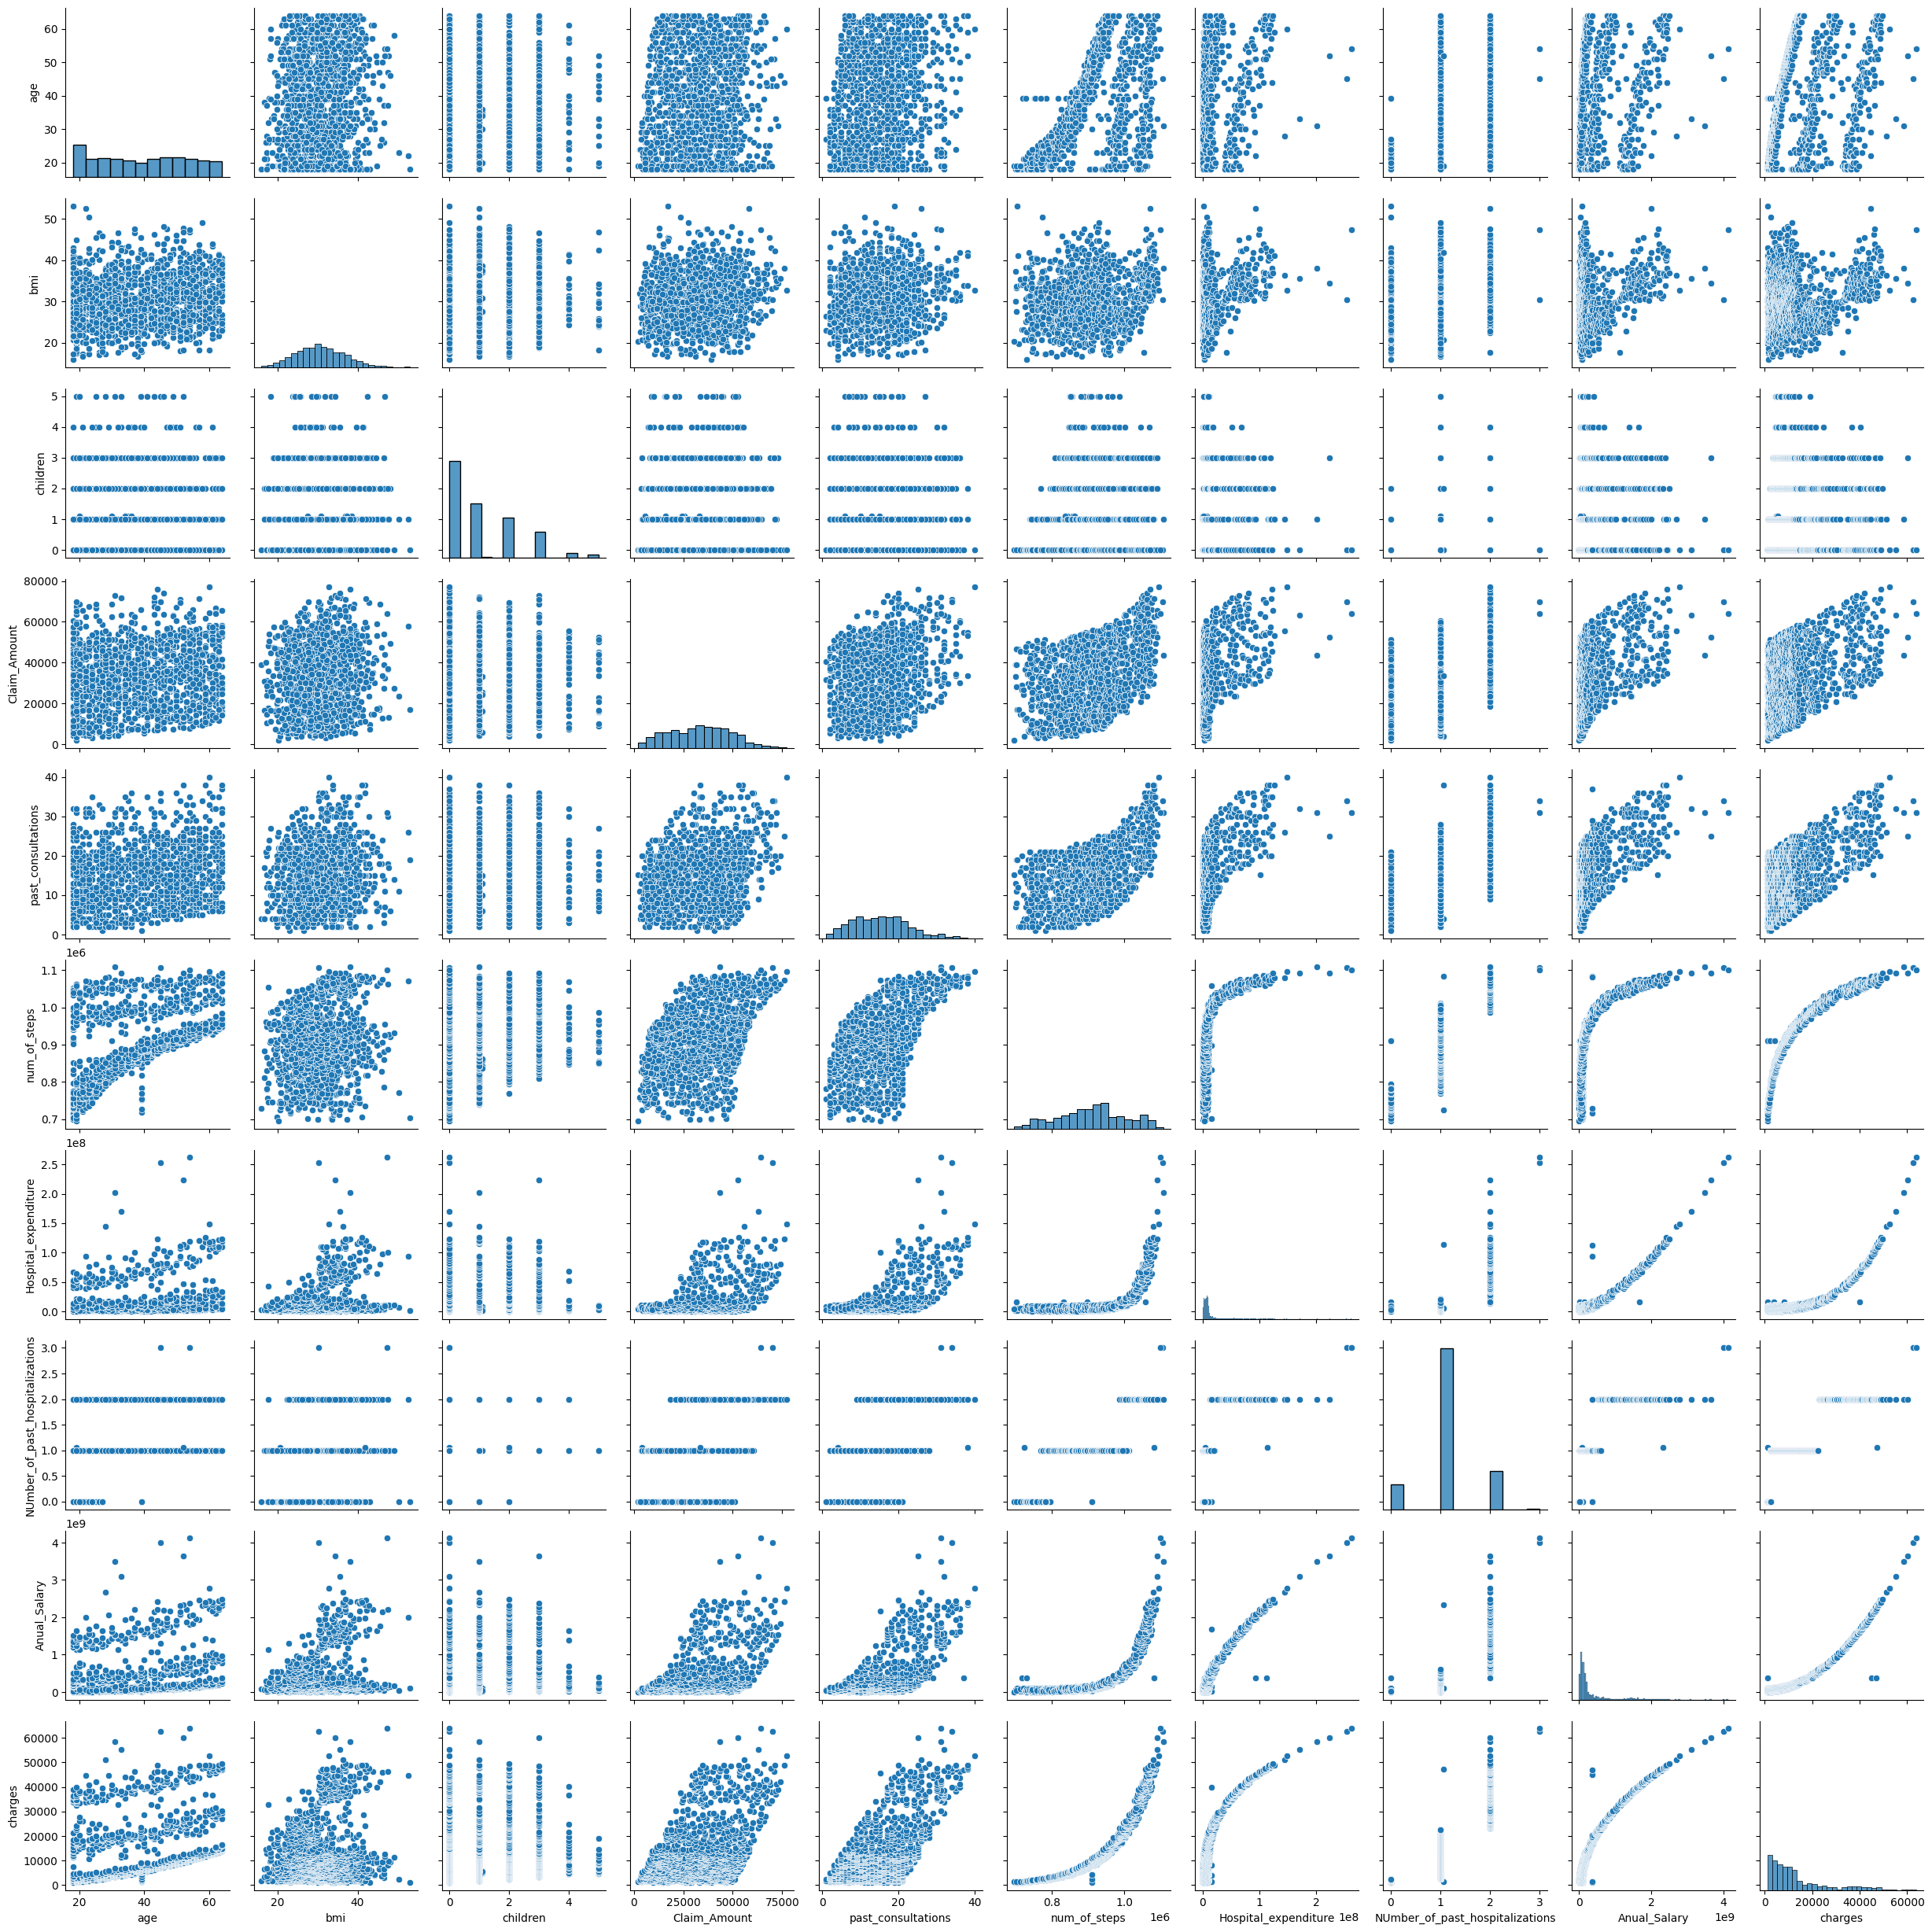

In [170]:
sns.pairplot(df)
plt.show()

In [171]:
# Outlier Removal

outlist = ['bmi','past_consultations','Hospital_expenditure','Anual_Salary']

for col in outlist:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)

  IQR =Q3-Q1

  LB = Q1 - 1.5*(IQR)
  UB = Q3 + 1.5*(IQR)

  df=df[(df[col]>LB )& (df[col]<UB)]

In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1030 entries, 0 to 1069
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1030 non-null   float64
 1   sex                              1030 non-null   object 
 2   bmi                              1030 non-null   float64
 3   children                         1030 non-null   float64
 4   smoker                           1030 non-null   object 
 5   Claim_Amount                     1030 non-null   float64
 6   past_consultations               1030 non-null   float64
 7   num_of_steps                     1030 non-null   float64
 8   Hospital_expenditure             1030 non-null   float64
 9   NUmber_of_past_hospitalizations  1030 non-null   float64
 10  Anual_Salary                     1030 non-null   float64
 11  region                           1030 non-null   object 
 12  charges                  

In [173]:
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.210,0.0,no,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.140,0.0,no,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.330,0.0,no,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.660,0.0,no,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.100,0.0,no,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1046,29.0,female,27.940,1.0,yes,51168.25474,23.0,993751.0,1.665982e+07,1.0,3.712188e+08,southeast,19107.77960
1048,31.0,male,25.900,3.0,yes,46619.40230,27.0,989387.0,1.361938e+07,1.0,3.812895e+08,southwest,19199.94400
1050,31.0,male,29.810,0.0,yes,24382.58056,21.0,973924.0,1.028991e+07,1.0,3.745310e+08,southeast,19350.36890
1062,43.0,female,20.045,2.0,yes,21596.43846,10.0,994419.0,1.083030e+07,1.0,3.696849e+08,northeast,19798.05455


In [174]:
# Label Encoding

# Convert object data into numerical data

In [175]:
from sklearn.preprocessing import LabelEncoder

In [176]:
LE = LabelEncoder()

In [177]:
for col in df.columns:
  if (df[col].dtype == 'object'):
   df[col]=LE.fit_transform(df[col])

In [26]:
# Fit - Learning something
# Transform - Applying that learning

In [178]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1030 entries, 0 to 1069
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1030 non-null   float64
 1   sex                              1030 non-null   int64  
 2   bmi                              1030 non-null   float64
 3   children                         1030 non-null   float64
 4   smoker                           1030 non-null   int64  
 5   Claim_Amount                     1030 non-null   float64
 6   past_consultations               1030 non-null   float64
 7   num_of_steps                     1030 non-null   float64
 8   Hospital_expenditure             1030 non-null   float64
 9   NUmber_of_past_hospitalizations  1030 non-null   float64
 10  Anual_Salary                     1030 non-null   float64
 11  region                           1030 non-null   int64  
 12  charges                  

In [179]:
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,1,23.210,0.0,0,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,2,1121.87390
1,18.0,1,30.140,0.0,0,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,2,1131.50660
2,18.0,1,33.330,0.0,0,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,2,1135.94070
3,18.0,1,33.660,0.0,0,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,2,1136.39940
4,18.0,1,34.100,0.0,0,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,2,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1046,29.0,0,27.940,1.0,1,51168.25474,23.0,993751.0,1.665982e+07,1.0,3.712188e+08,2,19107.77960
1048,31.0,1,25.900,3.0,1,46619.40230,27.0,989387.0,1.361938e+07,1.0,3.812895e+08,3,19199.94400
1050,31.0,1,29.810,0.0,1,24382.58056,21.0,973924.0,1.028991e+07,1.0,3.745310e+08,2,19350.36890
1062,43.0,0,20.045,2.0,1,21596.43846,10.0,994419.0,1.083030e+07,1.0,3.696849e+08,0,19798.05455


In [29]:
# Model Building

In [30]:
# splitting the data into x(independent) and y(dependent/target)

# splitting the data into training and testing

# Model Initilization

# Train the model

# Prediction

# Evaluation

In [180]:
x = df.iloc[:,:-1]

# x=df.drop(columns=['charges'])

In [181]:
x

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
0,18.0,1,23.210,0.0,0,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,2
1,18.0,1,30.140,0.0,0,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,2
2,18.0,1,33.330,0.0,0,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,2
3,18.0,1,33.660,0.0,0,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,2
4,18.0,1,34.100,0.0,0,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1046,29.0,0,27.940,1.0,1,51168.25474,23.0,993751.0,1.665982e+07,1.0,3.712188e+08,2
1048,31.0,1,25.900,3.0,1,46619.40230,27.0,989387.0,1.361938e+07,1.0,3.812895e+08,3
1050,31.0,1,29.810,0.0,1,24382.58056,21.0,973924.0,1.028991e+07,1.0,3.745310e+08,2
1062,43.0,0,20.045,2.0,1,21596.43846,10.0,994419.0,1.083030e+07,1.0,3.696849e+08,0


In [182]:
y = df['charges']
y

,charges
0,1121.87390
1,1131.50660
2,1135.94070
3,1136.39940
4,1137.01100
...,...
1046,19107.77960
1048,19199.94400
1050,19350.36890
1062,19798.05455


In [183]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.2, random_state = 42)

In [184]:
x_train

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
1001,27.0,0,24.750,0.0,1,53835.714590,13.000000,985207.0,1.251042e+07,1.0,2.997861e+08,2
509,46.0,1,22.300,0.0,0,39421.715810,11.000000,893621.0,8.322795e+06,1.0,7.356161e+07,3
336,35.0,1,27.610,1.0,0,45580.280500,15.216216,850393.0,6.640575e+05,1.0,5.521018e+07,2
854,60.0,1,25.740,0.0,0,10462.197210,15.000000,954922.0,8.333001e+06,1.0,2.155723e+08,2
296,32.0,0,29.735,0.0,0,16081.646280,10.000000,847357.0,8.748337e+04,1.0,9.833337e+07,1
...,...,...,...,...,...,...,...,...,...,...,...,...
88,20.0,1,33.000,1.0,0,9408.348963,14.000000,759062.0,2.503468e+06,0.0,1.780433e+07,3
332,30.0,0,22.895,1.0,0,32439.939850,11.000000,840452.0,3.852491e+06,1.0,9.007806e+07,0
468,36.0,1,28.595,3.0,0,38533.729650,4.000000,871870.0,9.075925e+06,1.0,1.281622e+08,1
122,18.0,0,40.185,0.0,0,45623.681360,18.000000,774465.0,3.561362e+06,0.0,3.826765e+07,0


In [185]:
x_test

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
32,18.000000,0,36.85,0.0,0,42510.441160,13.0,739413.0,3.456345e+06,0.0,7.155619e+07,2
110,22.000000,0,28.05,0.0,0,23409.828700,7.0,760526.0,8.996912e+06,0.0,7.086384e+06,2
137,23.000000,1,24.51,0.0,0,38358.041560,15.0,772972.0,2.346913e+06,0.0,5.426396e+07,0
89,24.000000,1,32.01,0.0,0,2912.590584,11.0,759197.0,7.899220e+06,0.0,4.031690e+07,2
924,56.000000,0,32.30,3.0,0,10876.549050,10.0,953663.0,9.505950e+06,1.0,2.728641e+08,0
...,...,...,...,...,...,...,...,...,...,...,...,...
484,36.000000,1,27.55,3.0,0,49292.199920,7.0,868270.0,3.732688e+05,1.0,8.403831e+07,0
547,38.000000,0,30.21,3.0,0,21969.960480,16.0,894028.0,4.983099e+06,1.0,7.423690e+07,1
111,39.310008,0,28.82,0.0,0,43225.257010,18.0,784583.0,1.110036e+06,0.0,2.128683e+07,2
516,42.000000,1,37.18,2.0,0,51466.023220,16.0,881594.0,3.901163e+05,1.0,6.759640e+07,2


In [37]:
y_train

,charges
1001,16577.77950
509,7147.10500
336,4747.05290
854,12142.57860
296,4357.04365
...,...
88,1980.07000
332,4719.52405
468,6548.19505
122,2217.46915


In [38]:
y_test

,charges
32,1629.8335
110,2155.6815
137,2396.0959
89,1981.5819
924,13430.2650
...,...
484,6746.7425
547,7537.1639
111,2156.7518
516,7162.0122


In [228]:
from sklearn.linear_model import LinearRegression

In [229]:
model = LinearRegression()
model.fit(x_train , y_train)

LinearRegression()

In [230]:
y_pred = model.predict(x_test)

In [231]:
y_pred

array([ 1423.44953761,  1469.96518392,  2687.35820135,  1860.51696794,
       13873.92358645, 18812.69554158, 11543.35626025,  3773.67624268,
        4146.16497042,  8206.40842691, 12768.12348125,  8493.65005496,
         870.23935836,  2697.78700702,  6723.49619896,  8076.1709214 ,
       11686.63770707,  8929.32575587, 10823.93302395,  6114.08005374,
        7811.06330036,  5793.08214339,  5113.65300923,  8382.34158888,
        5318.7205309 ,  4773.43580051,  9196.14451051, 13508.55342178,
        7237.66485312,  8116.66000944,  6007.29455456,  7509.47120411,
       10537.79783051,  5865.80293039,  5651.94634007,   863.60947203,
        4290.48959471, 13722.54851423,  8903.65131991,  4467.14058062,
        9143.0079089 ,  9833.13765007, -1614.95001047,  8698.02383454,
        3456.21902837,  3616.26963888,  5463.17288396,  9763.9511499 ,
       11785.36516149, 10600.15362028, 12370.82540118,  9822.50735366,
       12723.1178182 ,  8368.49874866,  4867.99423005,   493.37613335,
      

In [114]:
result = pd.DataFrame(columns=['Actual','Prediction'])
result['Actual'] = y_test
result['Prediction'] = y_pred
result

,Actual,Prediction
32,1629.8335,1423.449538
110,2155.6815,1469.965184
137,2396.0959,2687.358201
89,1981.5819,1860.516968
924,13430.2650,13873.923586
...,...,...
484,6746.7425,6300.388375
547,7537.1639,7373.631254
111,2156.7518,3277.147169
516,7162.0122,6673.898228


In [190]:
from sklearn.metrics import *

res= r2_score(y_test,y_pred)
res

0.969467777821272

In [191]:
res*100

96.9467777821272

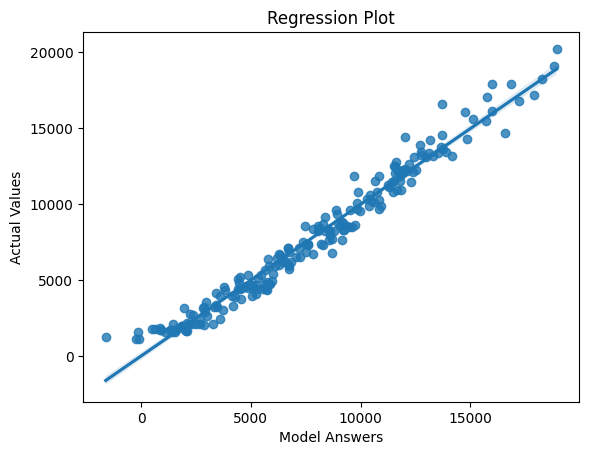

In [241]:
sns.regplot(x=y_pred, y=y_test)
plt.title("Regression Plot")
plt.xlabel("Model Answers")
plt.ylabel('Actual Values')
plt.show()

In [242]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print('MAE:', mae)
print('MSE:', mse)
print('RMSE:', rmse)

MAE: 602.048619984252
MSE: 615024.3512192704
RMSE: 784.2348826845631


In [243]:
# Decision Tree Regression

In [244]:
from sklearn.tree import DecisionTreeRegressor

In [245]:
model1= DecisionTreeRegressor(random_state=42)

In [246]:
model1.fit(x_train,y_train)

DecisionTreeRegressor(random_state=42)

In [247]:
y_pred= model1.predict(x_test)

In [248]:
y_pred

array([ 1744.465  ,  2102.2647 ,  2416.955  ,  1737.376  , 14571.8908 ,
       17081.08   , 12982.8747 ,  4149.736  ,  4391.652  ,  7046.7222 ,
       13470.8044 ,  9704.66805,  1711.0268 ,  1909.52745,  5934.3798 ,
        8569.8618 , 12644.589  ,  8601.3293 , 10601.412  ,  5920.1041 ,
        7954.517  ,  6067.12675,  4571.41305,  9778.3472 ,  4992.3764 ,
        4438.2634 ,  9487.6442 , 13390.559  ,  7173.35995,  7526.70645,
        5920.1041 ,  7441.053  , 10107.2206 ,  4894.7533 ,  5584.3057 ,
        1731.677  ,  3925.7582 , 13126.67745,  8601.3293 ,  4260.744  ,
        8569.8618 , 10085.846  ,  1242.816  ,  7742.1098 ,  3046.062  ,
        2459.7201 ,  5373.36425,  8538.28845, 11931.12525,  9957.7216 ,
       11326.71487, 10096.97   , 13462.52   ,  7518.02535,  4837.5823 ,
        1906.35825,  3490.5491 , 12032.326  ,  7281.5056 ,  7196.867  ,
       12950.0712 , 10435.06525,  3309.7926 ,  1909.52745, 10106.13425,
       12333.828  , 16796.41194, 11362.755  ,  3537.703  ,  3500

In [249]:
result1 =pd.DataFrame(columns=['Actual','Prediction'])
result1['Actual']=y_test
result1['Prediction']=y_pred
result

,Actual,Prediction
32,1629.8335,1423.449538
110,2155.6815,1469.965184
137,2396.0959,2687.358201
89,1981.5819,1860.516968
924,13430.2650,13873.923586
...,...,...
484,6746.7425,6300.388375
547,7537.1639,7373.631254
111,2156.7518,3277.147169
516,7162.0122,6673.898228


In [250]:
from sklearn.metrics import *

In [251]:
res1=r2_score(y_test,y_pred)
res1

0.9708096583607462

In [253]:
res1*100

97.08096583607461

In [203]:
mae1 = mean_absolute_error(y_test, y_pred)
mse1 = mean_squared_error(y_test, y_pred)
rmse1 = np.sqrt(mse1)
print('MAE:', mae1)
print('MSE:', mse1)
print('RMSE:', rmse1)

MAE: 506.5737674757282
MSE: 587994.2450130199
RMSE: 766.8078279549707


In [129]:
# Random Forest Regressor

In [130]:
from sklearn.ensemble import RandomForestRegressor

In [102]:
model2 = RandomForestRegressor(n_estimators=100, random_state =42)

In [208]:
model2.fit(x_train,y_train)

RandomForestRegressor(random_state=42)

In [209]:
y_pred= model2.predict(x_test)

In [210]:
y_pred

array([ 1642.97611   ,  2019.741877  ,  2333.9922915 ,  1963.44206   ,
       13972.6761884 , 18228.75786   , 12029.431558  ,  4430.600342  ,
        4290.3543545 ,  7532.8232405 , 13548.793183  ,  8997.7835895 ,
        1699.8970125 ,  2010.7147805 ,  6550.31919169,  8500.948107  ,
       12389.201767  ,  9049.310355  , 11276.241875  ,  5961.474158  ,
        8092.19202919,  5989.226488  ,  4600.703849  ,  8940.7306005 ,
        4981.47322   ,  4458.306595  ,  9521.4068105 , 13576.1650372 ,
        7105.34936969,  8276.26005469,  5980.4491385 ,  7348.7994    ,
       10457.0403588 ,  4895.268249  ,  5637.4356355 ,  1754.6402685 ,
        3736.285499  , 13455.4341533 ,  9134.983812  ,  4495.513852  ,
        8584.587926  , 10229.87849   ,  1268.554515  ,  7838.42305288,
        3340.6875755 ,  2507.3052015 ,  5368.8555335 ,  9100.5104835 ,
       11715.9367555 ,  9806.6678245 , 11847.8406301 ,  9662.8377605 ,
       13493.0547405 ,  7686.13905619,  4688.4874575 ,  1872.563189  ,
      

In [211]:
result2 = pd.DataFrame(columns=['Actual','Prediction'])
result2['Actual']=y_test
result2['Prediction']=y_pred
result2

,Actual,Prediction
32,1629.8335,1642.976110
110,2155.6815,2019.741877
137,2396.0959,2333.992291
89,1981.5819,1963.442060
924,13430.2650,13972.676188
...,...,...
484,6746.7425,5728.894036
547,7537.1639,7182.345532
111,2156.7518,2485.532606
516,7162.0122,6821.407347


In [212]:
from sklearn.metrics import *

In [214]:
res2 = r2_score(y_test,y_pred)
res2

0.9899384179776073

In [254]:
res2*100

98.99384179776072

In [215]:
mae2 = mean_absolute_error(y_test, y_pred)
mse2 = mean_squared_error(y_test, y_pred)
rmse2 = np.sqrt(mse2)
print('MAE:', mae2)
print('MSE:', mse2)
print('RMSE:', rmse2)

MAE: 332.23091942262147
MSE: 202674.99428432877
RMSE: 450.19439610498125


In [140]:
# XGBBoost Regressor

In [216]:
from xgboost import XGBRegressor

In [217]:
model3 = XGBRegressor(random_state=42)

In [218]:
model3.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [219]:
y_pred = model3.predict(x_test)
y_pred

array([ 1558.9086,  2009.6011,  2379.7312,  2053.422 , 14335.931 ,
       18787.826 , 12277.891 ,  4185.867 ,  4195.6133,  7381.2383,
       12835.865 ,  9123.746 ,  1758.3156,  1992.9457,  6554.855 ,
        8562.899 , 12545.372 ,  9136.382 , 11446.919 ,  5910.0312,
        8166.696 ,  6642.4253,  4510.99  ,  8800.402 ,  4757.366 ,
        4314.8096,  9305.367 , 12954.423 ,  6799.683 ,  8158.3535,
        5753.236 ,  7313.7173,  9884.168 ,  4734.0024,  5664.7524,
        1762.657 ,  3894.9185, 14344.547 ,  9432.709 ,  4342.725 ,
        8693.714 , 10210.72  ,  1126.9347,  7806.771 ,  3438.2075,
        2678.0222,  5217.1245,  8835.914 , 11843.109 ,  9512.472 ,
       11683.71  ,  9687.7705, 13373.682 ,  7967.9287,  4725.064 ,
        1870.9795,  3356.3083, 12007.778 ,  6637.769 ,  8319.057 ,
       12484.301 , 11727.966 ,  3709.593 ,  1927.1708,  9374.685 ,
       12029.776 , 17043.838 , 12026.84  ,  3304.7756,  3826.2798,
        5500.458 , 10005.639 ,  8181.551 , 14669.408 , 12442.6

In [221]:
result3 = pd.DataFrame(columns=['Actual','Prediction'])
result3['Actual']=y_test
result3['Prediction']=y_pred
result3

,Actual,Prediction
32,1629.8335,1558.908569
110,2155.6815,2009.601074
137,2396.0959,2379.731201
89,1981.5819,2053.422119
924,13430.2650,14335.930664
...,...,...
484,6746.7425,5987.645508
547,7537.1639,7059.445312
111,2156.7518,2561.946289
516,7162.0122,6902.732910


In [222]:
from sklearn.metrics import *

In [223]:
res3 = r2_score(y_test,y_pred)
res3

0.9888389440970998

In [225]:
res3*100

98.88389440970998

In [226]:
mae3 = mean_absolute_error(y_test, y_pred)
mse3 = mean_squared_error(y_test, y_pred)
rmse3 = np.sqrt(mse3)
print('MAE:', mae3)
print('MSE:', mse3)
print('RMSE:', rmse3)

MAE: 350.9017700123255
MSE: 224822.1935966928
RMSE: 474.1541875768818


In [95]:
comparision = pd.DataFrame(result)

In [96]:
print(comparision.columns)

Index(['Actual', 'Prediction'], dtype='object')


In [232]:
results = [
    {
        "Model": "Linear Regression",
        "R2 Score": res,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse
    },
    {
        "Model": "Decision Tree",
        "R2 Score": res1,
        "MAE": mae1,
        "MSE": mse1,
        "RMSE":rmse1
    },
    {
        "Model": "Random Forest",
        "R2 Score": res2,
        "MAE": mae2,
        "MSE": mse2,
        "RMSE": rmse2
    },
    {
        "Model": "XGBoost",
        "R2 Score": res3,
        "MAE": mae3,
        "MSE": mse3,
        "RMSE": rmse3
    }
]

comparison = pd.DataFrame(results)
comparison = comparison.sort_values(by="R2 Score", ascending=False)

print(comparison)

               Model  R2 Score         MAE            MSE        RMSE
2      Random Forest  0.989938  332.230919  202674.994284  450.194396
3            XGBoost  0.988839  350.901770  224822.193597  474.154188
1      Decision Tree  0.970810  506.573767  587994.245013  766.807828
0  Linear Regression  0.969468  602.048620  615024.351219  784.234883


In [233]:
import joblib
joblib.dump(model,'insurance_model.pkl')

['insurance_model.pkl']

In [ ]:
# Model Comparision

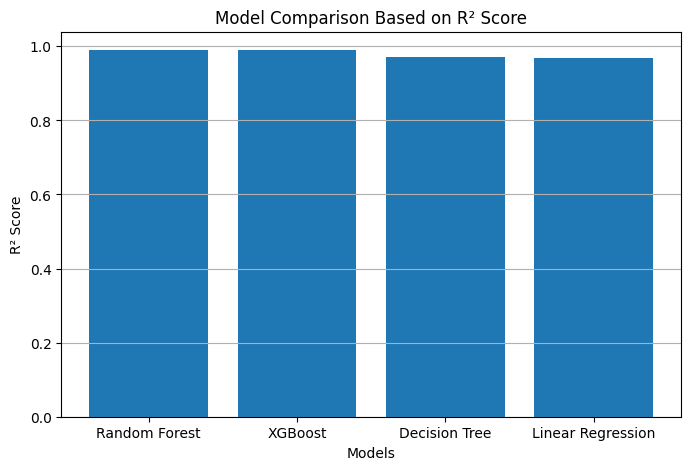

In [237]:
plt.figure(figsize=(8,5))
plt.bar(comparison['Model'], comparison['R2 Score'])
plt.title('Model Comparison Based on R² Score')
plt.xlabel('Models')
plt.ylabel('R² Score')
plt.grid(axis='y')
plt.show()

In [ ]:
# Actual and Predictes Values (Best Model - Random Forest)

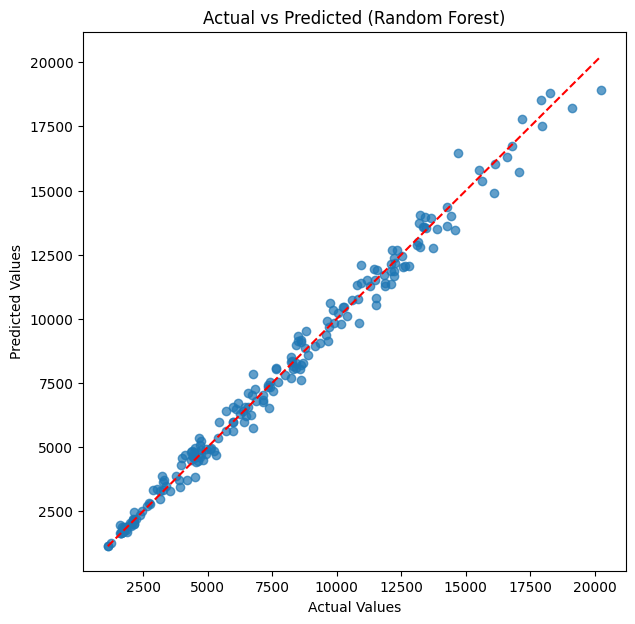

In [238]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, model2.predict(x_test), alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

In [ ]:
# Compare Error

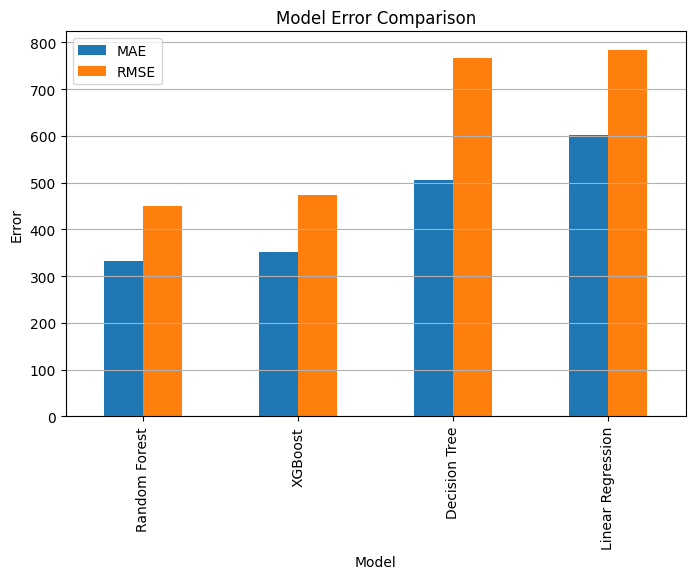

In [239]:
comparison.plot(
    x='Model',
    y=['MAE','RMSE'],
    kind='bar',
    figsize=(8,5)
)

plt.title("Model Error Comparison")
plt.ylabel("Error")
plt.grid(axis='y')
plt.show()

In [ ]:
# Feature Importance (Random Forest)

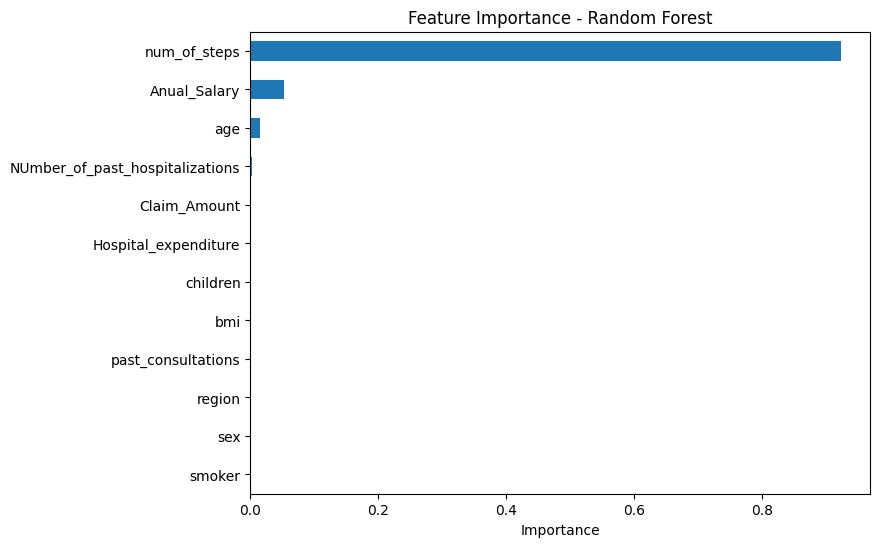

In [240]:
importance = pd.Series(model2.feature_importances_, index=x_train.columns)
importance.sort_values().plot(kind='barh', figsize=(8,6))

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.show()

In [234]:
model = joblib.dump(model,'insurance_model.pkl')

In [236]:
model

['insurance_model.pkl']


---
<br><br>
**Project Summary**

This project focuses on predicting medical insurance charges using machine learning regression algorithms. The dataset contains demographic and lifestyle-related features such as age, gender, Body Mass Index (BMI), children, smoking status, and residential region etc,. which influence medical insurance costs.

The primary objective of this project is to develop accurate predictive models and compare their performance to determine the most suitable algorithm for insurance cost prediction. During the project, the dataset was carefully preprocessed by handling missing values, removing outliers, encoding categorical variables, and splitting the data into training and testing sets. Four regression algorithms—Linear Regression, Decision Tree Regressor, Random Forest Regressor, and XGBoost Regressor—were trained and evaluated using standard performance metrics.
<br><br>

---
<br><br>

**Problem Statement**

<br>

Healthcare insurance companies need accurate estimates of medical insurance charges to make informed pricing decisions. Predicting these costs manually can be difficult because they depend on multiple demographic and lifestyle factors. The objective of this project is to build a machine learning model that predicts medical insurance charges based on customer information and to compare different regression algorithms to identify the model that provides the highest prediction accuracy with the lowest prediction error.

<br>
<br>

---

<br><br>
**Project Objectives**

<br>

1. Predict medical insurance charges using machine learning.

2. Analyze the impact of customer features on insurance costs.

3. Preprocess the dataset by handling missing values and outliers.

4. Encode categorical variables for model training.

5. Train multiple regression models.

6. Evaluate models using R² Score, MAE, MSE, and RMSE.

7. Identify the best-performing regression model.

<br><br>

---

<br><br>
Project Workflow

<br>

1. Imported the required Python libraries.


2. Loaded and explored the dataset.


3. Checked dataset information and summary statistics.


4. Identified and handled missing values.


5. Checked and removed duplicate records.


6. Detected and removed outliers using the IQR method.


7. Applied Label Encoding to categorical variables.


8. Split the dataset into training and testing sets.


9. Built four regression models:

 Linear Regression

 Decision Tree Regressor

 Random Forest Regressor

 XGBoost Regressor



10. Evaluated each model using performance metrics.


11. Compared the performance of all models.


12. Selected the best-performing model.


<br><br>

---
<br><br>
**Performance Comparison**

<br>


1. Model - Random Forest Regressor

   R² Score Performance - 98.99% ⭐ Best

2. Model - XGBoost Regressor

   R² Score Performance - 98.88% Excellent

3. Model - Decision Tree Regressor

   R² Score Performance - 97.08% Very Good

4. Model - Linear Regression

   R² Score Performance - 96.95% Good

<br><br>

---

<br><br>

**Conclusion**

<br>

This project successfully demonstrated how machine learning can be used to predict medical insurance charges with high accuracy. Multiple regression algorithms were implemented and compared using standard evaluation metrics.

Among all the models, the Random Forest Regressor achieved the highest R² Score (approximately 98.99%) while also producing the lowest prediction errors (MAE, MSE, and RMSE). This indicates that Random Forest captured the relationships within the dataset more effectively than the other algorithms.

The comparison also showed that ensemble learning techniques such as Random Forest and XGBoost outperform traditional Linear Regression for this dataset. Therefore, Random Forest Regressor was selected as the final model for predicting medical insurance charges.

<br><br>

---

**Key Learnings**

<br>

1. Through this project, I gained practical experience in:

2. Data preprocessing techniques.

3. Handling missing values.

4. Detecting and removing outliers.

5. Label Encoding categorical variables.

6. Splitting data into training and testing sets.

7. Training multiple machine learning regression models.

8. Model evaluation using R² Score, MAE, MSE, and RMSE.

9. Comparing different regression algorithms.

10. Selecting the most suitable predictive model.

<br><br>

---

<br>

**Future Scope**

<br>

1. This project can be enhanced in several ways:

2. Perform Hyperparameter Tuning using GridSearchCV or RandomizedSearchCV.

3. Apply Feature Engineering to improve model performance.

4. Experiment with additional regression algorithms.

5. Build an interactive web application using Streamlit or Flask.

6. Deploy the trained model on cloud platforms.

7. Use larger and more diverse real-world datasets to improve generalization.

<br><br>

---
<br>

**Final Result**

🏆 Random Forest Regressor was selected as the best-performing model because it achieved:

Highest R² Score: 98.99%

Lowest MAE - 332.230919  

Lowest MSE -  202674.994284

Lowest RMSE - 450.194396


Therefore, Random Forest is the recommended model for predicting medical insurance charges on this dataset.


---
<br><br>

**Thank You**

<br>

Thank you for reviewing this project.

This project demonstrates practical knowledge of Python, Data Preprocessing, Exploratory Data Analysis (EDA), Feature Engineering, Machine Learning, Model Evaluation, and Regression Algorithms, and showcases the complete workflow of building a predictive machine learning solution.

<br><br>

---
